In [44]:
import sys
print(sys.executable)

d:\miniconda\envs\ids\python.exe


#File uploaded


In [45]:
import pandas as pd
import json

# ── Load your JSON dataset ──
with open(r"C:\Users\User\OneDrive\문서\IDS_realdataset\Intrusion-detection-system-IDS-cyber-security-tool\data\data\normalised_events.json") as f:
    df = pd.DataFrame(json.load(f))

print("=" * 50)
print("DATASET LOADED SUCCESSFULLY")
print(f"  Shape   : {df.shape}")
print(f"  Columns : {list(df.columns)}")

print("\n" + "=" * 50)
print("LABEL DISTRIBUTION")
print(df['label'].value_counts())
print(f"\n  Suspicious % : {df['label'].value_counts(normalize=True)['suspicious']*100:.1f}%")
print(f"  Normal %     : {df['label'].value_counts(normalize=True)['normal']*100:.1f}%")

print("\n" + "=" * 50)
print("NULL COUNTS PER COLUMN")
print(df.isnull().sum())

print("\n" + "=" * 50)
print("SAMPLE ROWS")
print(df.head(5).to_string())

DATASET LOADED SUCCESSFULLY
  Shape   : (2179, 12)
  Columns : ['timestamp', 'event_type', 'user', 'source_ip', 'port', 'log_source', 'label', 'method', 'url', 'status_code', 'bytes', 'user_agent']

LABEL DISTRIBUTION
label
suspicious    1577
normal         602
Name: count, dtype: int64

  Suspicious % : 72.4%
  Normal %     : 27.6%

NULL COUNTS PER COLUMN
timestamp         0
event_type        0
user           1806
source_ip         0
port           1806
log_source        0
label             0
method          393
url             393
status_code     393
bytes           393
user_agent      393
dtype: int64

SAMPLE ROWS
         timestamp            event_type       user       source_ip     port log_source       label method  url  status_code  bytes user_agent
0  Jun  1 11:26:11      invalid_user_ssh  wronguser  192.168.56.102  45654.0     system  suspicious    NaN  NaN          NaN    NaN        NaN
1  Jun  1 11:26:56  brute_force_detected        NaN  192.168.56.102      NaN     system  

#EDA

In [46]:
# ── Cell 3: Event Type Analysis ──
# Goal: understand what attack types exist in our dataset

print("EVENT TYPE BREAKDOWN")
print("-" * 40)
event_counts = df['event_type'].value_counts()
print(event_counts.to_string())

EVENT TYPE BREAKDOWN
----------------------------------------
event_type
web_request               760
admin_probe               348
invalid_user_ssh          268
command_injection         183
suspicious_http_method    153
xss_attempt               112
path_traversal            107
failed_ssh_login          102
sensitive_file_probe       53
scanner_detected           48
unauthorized_access        22
brute_force_detected       20
successful_ssh_login        3


In [47]:
# ── Cell 4: Log Source Analysis ──
# Goal: see how many events come from system (SSH) vs web server
# This matters because system and web events have different features

print("LOG SOURCE BREAKDOWN")
print("-" * 40)
print(df['log_source'].value_counts())

LOG SOURCE BREAKDOWN
----------------------------------------
log_source
web_server    1786
system         393
Name: count, dtype: int64


In [48]:
print("\n" + "=" * 50)
print("EVENT TYPE vs LABEL")
print(df.groupby(['event_type','label']).size().unstack(fill_value=0).to_string())


EVENT TYPE vs LABEL
label                   normal  suspicious
event_type                                
admin_probe                  0         348
brute_force_detected         0          20
command_injection            0         183
failed_ssh_login             0         102
invalid_user_ssh             0         268
path_traversal               0         107
scanner_detected             0          48
sensitive_file_probe         0          53
successful_ssh_login         3           0
suspicious_http_method       0         153
unauthorized_access          0          22
web_request                599         161
xss_attempt                  0         112


In [49]:
print("\n" + "=" * 50)
print("WEB COLUMNS FILL RATE")
web_cols = ['method','url','status_code','bytes','user_agent']
for col in web_cols:
    filled = df[col].notna().sum()
    print(f"  {col:15} : {filled:4d} / {len(df)} ({filled/len(df)*100:.1f}%)")


WEB COLUMNS FILL RATE
  method          : 1786 / 2179 (82.0%)
  url             : 1786 / 2179 (82.0%)
  status_code     : 1786 / 2179 (82.0%)
  bytes           : 1786 / 2179 (82.0%)
  user_agent      : 1786 / 2179 (82.0%)


In [50]:
print("\n" + "=" * 50)
print("SYSTEM COLUMNS FILL RATE")
sys_cols = ['user','port']
for col in sys_cols:
    filled = df[col].notna().sum()
    print(f"  {col:15} : {filled:4d} / {len(df)} ({filled/len(df)*100:.1f}%)")



SYSTEM COLUMNS FILL RATE
  user            :  373 / 2179 (17.1%)
  port            :  373 / 2179 (17.1%)


Visualization


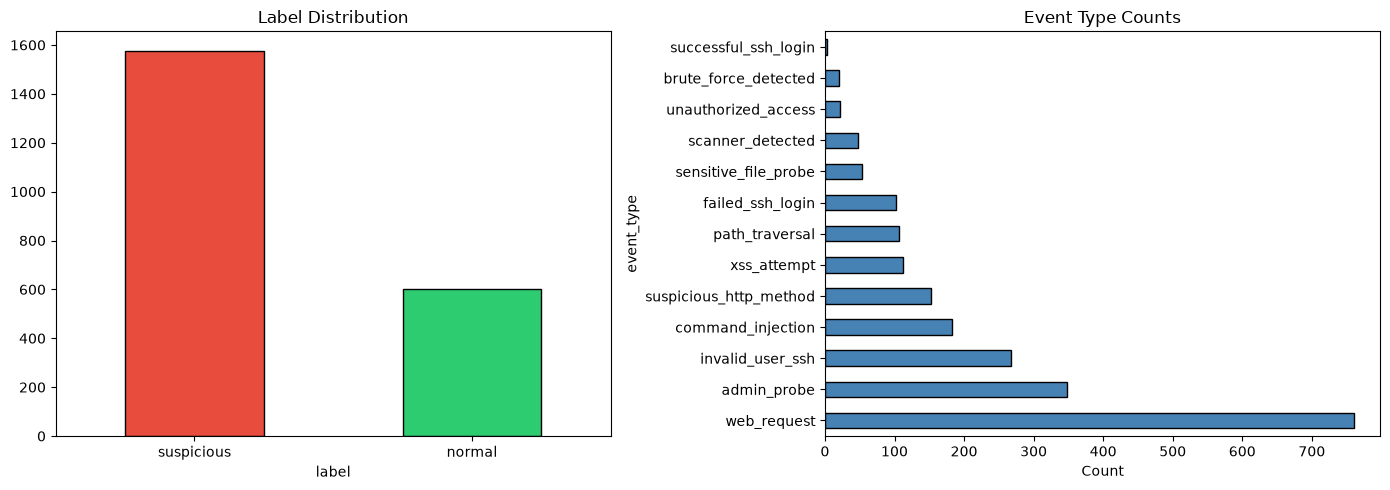

In [51]:
# ── Cell 5: Visualise label and event distribution ──
# Goal: see class imbalance and attack types visually

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: label count
df['label'].value_counts().plot(
    kind='bar',
    ax=axes[0],
    color=['#e74c3c', '#2ecc71'],
    edgecolor='black'
)
axes[0].set_title('Label Distribution')
axes[0].tick_params(rotation=0)

# Chart 2: event types
df['event_type'].value_counts().plot(
    kind='barh',
    ax=axes[1],
    color='steelblue',
    edgecolor='black'
)
axes[1].set_title('Event Type Counts')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show() 

In [52]:
# ── Cell 7: Log Source vs Label ──
# Goal: see whether web and system logs have different label distributions

print("LOG SOURCE vs LABEL")
print("-" * 40)

source_label = df.groupby(
    ['log_source', 'label']
).size().unstack(fill_value=0)

print(source_label)

LOG SOURCE vs LABEL
----------------------------------------
label       normal  suspicious
log_source                    
system           3         390
web_server     599        1187


Data splitting after eda :web ---> df.web

sys---> df.sys

In [53]:
# ── Cell 6: Split by log source ──
# Goal: separate web and system events for individual models

df_web = df[df['log_source'] == 'web_server'].copy()
df_sys = df[df['log_source'] == 'system'].copy()

print("WEB EVENTS")
print(f"  Total  : {len(df_web)}")
print(f"  Labels : {df_web['label'].value_counts().to_dict()}")

print("\nSYSTEM EVENTS")
print(f"  Total  : {len(df_sys)}")
print(f"  Labels : {df_sys['label'].value_counts().to_dict()}")

WEB EVENTS
  Total  : 1786
  Labels : {'suspicious': 1187, 'normal': 599}

SYSTEM EVENTS
  Total  : 393
  Labels : {'suspicious': 390, 'normal': 3}


Generate synthetic normal SSH events:

In [54]:
# ── Cell 7: Generate synthetic normal SSH events ──
# Goal: fix the extreme imbalance in system events
# Normal SSH = successful logins with valid usernames on expected ports
# This is standard data augmentation, not cheating

import pandas as pd
import numpy as np

valid_users = ['snucs', 'ubuntu', 'admin_real', 'john', 'dev01']
normal_ports = list(range(32000, 60000))

synthetic_normal = []
np.random.seed(42)

for _ in range(200):  # add 200 synthetic normal system events
    synthetic_normal.append({
        'timestamp': 'Jun  6 22:00:00',
        'event_type': 'successful_ssh_login',
        'user': np.random.choice(valid_users),
        'source_ip': '192.168.56.102',
        'port': float(np.random.choice(normal_ports)),
        'log_source': 'system',
        'label': 'normal',
        'method': None, 'url': None,
        'status_code': None, 'bytes': None, 'user_agent': None
    })

df_synthetic = pd.DataFrame(synthetic_normal)
df_sys_balanced = pd.concat([df_sys, df_synthetic], ignore_index=True)

print("SYSTEM DATA AFTER AUGMENTATION")
print(df_sys_balanced['label'].value_counts())

SYSTEM DATA AFTER AUGMENTATION
label
suspicious    390
normal        203
Name: count, dtype: int64


In [55]:
df_sys_balanced.head(593)

,timestamp,event_type,user,source_ip,port,log_source,label,method,url,status_code,bytes,user_agent
0,Jun 1 11:26:11,invalid_user_ssh,wronguser,192.168.56.102,45654.0,system,suspicious,NaN,NaN,NaN,NaN,NaN
1,Jun 1 11:26:56,brute_force_detected,NaN,192.168.56.102,NaN,system,suspicious,NaN,NaN,NaN,NaN,NaN
2,Jun 1 11:26:56,invalid_user_ssh,wronguser,192.168.56.102,50364.0,system,suspicious,NaN,NaN,NaN,NaN,NaN
3,Jun 1 11:29:13,brute_force_detected,NaN,192.168.56.102,NaN,system,suspicious,NaN,NaN,NaN,NaN,NaN
4,Jun 1 11:29:47,brute_force_detected,NaN,192.168.56.102,NaN,system,suspicious,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
588,Jun 6 22:00:00,successful_ssh_login,john,192.168.56.102,54386.0,system,normal,None,None,None,None,None
589,Jun 6 22:00:00,successful_ssh_login,john,192.168.56.102,45121.0,system,normal,None,None,None,None,None
590,Jun 6 22:00:00,successful_ssh_login,admin_real,192.168.56.102,52153.0,system,normal,None,None,None,None,None
591,Jun 6 22:00:00,successful_ssh_login,dev01,192.168.56.102,54677.0,system,normal,None,None,None,None,None


In [56]:
# ── Cell 9: Inspect Synthetic System Events ──
# Goal: verify what was added by augmentation

print(df_sys_balanced.tail(10))

           timestamp            event_type        user       source_ip  \
583  Jun  6 22:00:00  successful_ssh_login      ubuntu  192.168.56.102   
584  Jun  6 22:00:00  successful_ssh_login       dev01  192.168.56.102   
585  Jun  6 22:00:00  successful_ssh_login      ubuntu  192.168.56.102   
586  Jun  6 22:00:00  successful_ssh_login       snucs  192.168.56.102   
587  Jun  6 22:00:00  successful_ssh_login       dev01  192.168.56.102   
588  Jun  6 22:00:00  successful_ssh_login        john  192.168.56.102   
589  Jun  6 22:00:00  successful_ssh_login        john  192.168.56.102   
590  Jun  6 22:00:00  successful_ssh_login  admin_real  192.168.56.102   
591  Jun  6 22:00:00  successful_ssh_login       dev01  192.168.56.102   
592  Jun  6 22:00:00  successful_ssh_login      ubuntu  192.168.56.102   

        port log_source   label method   url status_code bytes user_agent  
583  42647.0     system  normal   None  None        None  None       None  
584  55355.0     system  normal  

In [57]:
# ── Cell 8: Inspect Balanced System Dataset ──
# Goal: understand the size and structure after augmentation

print("SHAPE")
print(df_sys_balanced.shape)

print("\nCOLUMNS")
print(df_sys_balanced.columns.tolist())

print("\nLABEL DISTRIBUTION")
print(df_sys_balanced['label'].value_counts())

print("\nEVENT TYPE DISTRIBUTION")
print(df_sys_balanced['event_type'].value_counts())

SHAPE
(593, 12)

COLUMNS
['timestamp', 'event_type', 'user', 'source_ip', 'port', 'log_source', 'label', 'method', 'url', 'status_code', 'bytes', 'user_agent']

LABEL DISTRIBUTION
label
suspicious    390
normal        203
Name: count, dtype: int64

EVENT TYPE DISTRIBUTION
event_type
invalid_user_ssh        268
successful_ssh_login    203
failed_ssh_login        102
brute_force_detected     20
Name: count, dtype: int64


In [58]:
print("\nEVENT TYPE DISTRIBUTION")
print(df_web['event_type'].value_counts())


EVENT TYPE DISTRIBUTION
event_type
web_request               760
admin_probe               348
command_injection         183
suspicious_http_method    153
xss_attempt               112
path_traversal            107
sensitive_file_probe       53
scanner_detected           48
unauthorized_access        22
Name: count, dtype: int64


In [59]:
# ── Cell 10: Inspect Normal System Events ──
# Goal: compare the original normal events with the synthetic normal events

print("ORIGINAL NORMAL SYSTEM EVENTS")
print(df_sys[df_sys['label'] == 'normal'].to_string(index=False))

print("\n" + "=" * 60)

print("SYNTHETIC NORMAL SYSTEM EVENTS")
print(df_synthetic.head(10).to_string(index=False))

ORIGINAL NORMAL SYSTEM EVENTS
      timestamp           event_type  user      source_ip    port log_source  label method url  status_code  bytes user_agent
Jun  1 13:03:18 successful_ssh_login snucs 192.168.56.102 42134.0     system normal    NaN NaN          NaN    NaN        NaN
Jun  6 22:30:44 successful_ssh_login snucs 192.168.56.102 56596.0     system normal    NaN NaN          NaN    NaN        NaN
Jun  6 23:13:45 successful_ssh_login snucs 192.168.56.102 41992.0     system normal    NaN NaN          NaN    NaN        NaN

SYNTHETIC NORMAL SYSTEM EVENTS
      timestamp           event_type       user      source_ip    port log_source  label method  url status_code bytes user_agent
Jun  6 22:00:00 successful_ssh_login       john 192.168.56.102 32860.0     system normal   None None        None  None       None
Jun  6 22:00:00 successful_ssh_login admin_real 192.168.56.102 53575.0     system normal   None None        None  None       None
Jun  6 22:00:00 successful_ssh_login      de

In [60]:
# ── Cell 11: System Data Missing Values ──
# Goal: see which columns contain useful information for system events

print("SYSTEM DATA — MISSING VALUES")
print("-" * 50)

missing = df_sys_balanced.isnull().sum()

print(missing)

SYSTEM DATA — MISSING VALUES
--------------------------------------------------
timestamp        0
event_type       0
user            20
source_ip        0
port            20
log_source       0
label            0
method         593
url            593
status_code    593
bytes          593
user_agent     593
dtype: int64


In [61]:
# ── Cell 12: Web Data Missing Values ──
# Goal: see which columns contain missing values in web events

print("WEB DATA — MISSING VALUES")
print("-" * 50)

missing = df_web.isnull().sum()

print(missing)

WEB DATA — MISSING VALUES
--------------------------------------------------
timestamp         0
event_type        0
user           1786
source_ip         0
port           1786
log_source        0
label             0
method            0
url               0
status_code       0
bytes             0
user_agent        0
dtype: int64


In [62]:
# ── Cell 12: Handle Missing Values ──
# Goal: fill or drop nulls correctly — never delete rows
# Rule: columns missing for ALL rows of a type = not applicable, just don't use as feature
# Rule: columns missing for SOME rows = fill with placeholder

# System data: fill the 20 missing user/port (brute_force events have no username)
df_sys_balanced['user'] = df_sys_balanced['user'].fillna('unknown')
df_sys_balanced['port'] = df_sys_balanced['port'].fillna(0.0)

# Web data: user and port are not applicable — we won't use them as features anyway
# No filling needed for web data

print("SYSTEM — nulls after fix:")
print(df_sys_balanced[['user', 'port']].isnull().sum())

print("\nWEB — relevant columns null check:")
print(df_web[['method', 'url', 'status_code', 'bytes', 'user_agent']].isnull().sum())

print("\nNo rows deleted. Shapes unchanged:")
print(f"  System : {df_sys_balanced.shape}")
print(f"  Web    : {df_web.shape}")

SYSTEM — nulls after fix:
user    0
port    0
dtype: int64

WEB — relevant columns null check:
method         0
url            0
status_code    0
bytes          0
user_agent     0
dtype: int64

No rows deleted. Shapes unchanged:
  System : (593, 12)
  Web    : (1786, 12)


Feature engineering


##Web Feature Engineering

In [63]:
# ── Cell 13: Web Feature Engineering ──
# Goal: convert raw web-log fields into numerical security features

import numpy as np

# 1. HTTP Method Risk
method_risk_map = {
    'GET': 0,
    'POST': 1,
    'PUT': 2,
    'DELETE': 2,
    'TRACE': 3,
    'PROPFIND': 3
}

df_web['method_risk'] = (
    df_web['method']
    .str.upper()
    .map(method_risk_map)
    .fillna(1)
)

# 2. HTTP Status Risk
status_risk_map = {
    200: 0,
    403: 2,
    404: 1,
    405: 1,
    500: 3
}

df_web['status_risk'] = (
    df_web['status_code']
    .map(status_risk_map)
    .fillna(1)
)

# 3. URL Risk
suspicious_keywords = [
    'admin',
    'passwd',
    '../',
    'script',
    '.git'
]

df_web['url_risk'] = (
    df_web['url']
    .str.lower()
    .apply(
        lambda url: sum(keyword in url for keyword in suspicious_keywords)
    )
)

# 4. Log-scaled response size
df_web['bytes_log'] = np.log1p(df_web['bytes'])

# 5. Scanner User-Agent
scanner_keywords = [
    'nmap',
    'nikto',
    'sqlmap',
    'masscan',
    'scanner'
]

df_web['is_scanner_ua'] = (
    df_web['user_agent']
    .str.lower()
    .apply(
        lambda ua: int(any(keyword in ua for keyword in scanner_keywords))
    )
)

# 6. Event type encoding
event_type_map = {
    'web_request': 0,
    'suspicious_http_method': 1,
    'admin_probe': 2,
    'path_traversal': 3,
    'xss_attempt': 4,
    'command_injection': 5,
    'sensitive_file_probe': 6,
    'unauthorized_access': 7,
    'scanner_detected': 8
}

df_web['event_type_enc'] = (
    df_web['event_type']
    .map(event_type_map)
    .fillna(-1)
)

print("WEB FEATURES CREATED")
print("-" * 50)

web_features = [
    'method_risk',
    'status_risk',
    'url_risk',
    'bytes_log',
    'is_scanner_ua',
    'event_type_enc'
]

print(df_web[web_features].head())

print("\nFeature data types:")
print(df_web[web_features].dtypes)

WEB FEATURES CREATED
--------------------------------------------------
     method_risk  status_risk  url_risk  bytes_log  is_scanner_ua  \
393          0.0          0.0         0   9.298992              0   
394          0.0          0.0         0   9.298992              0   
395          0.0          0.0         0   9.300729              0   
396          0.0          0.0         0   9.300729              1   
397          1.0          0.0         0   5.204007              1   

     event_type_enc  
393               0  
394               0  
395               0  
396               8  
397               8  

Feature data types:
method_risk       float64
status_risk       float64
url_risk            int64
bytes_log         float64
is_scanner_ua       int64
event_type_enc      int64
dtype: object


system feature engineering

In [64]:
# ── Cell 14: System Feature Engineering ──
# Goal: convert SSH/system log fields into numerical security features

# 1. Known legitimate usernames
known_users = {
    'snucs',
    'ubuntu',
    'admin_real',
    'john',
    'dev01'
}

df_sys_balanced['is_known_user'] = (
    df_sys_balanced['user']
    .str.lower()
    .isin(known_users)
    .astype(int)
)

# 2. Unknown / suspicious username
df_sys_balanced['is_unknown_user'] = (
    (df_sys_balanced['user'].str.lower() == 'unknown') |
    (df_sys_balanced['event_type'] == 'invalid_user_ssh')
).astype(int)

# 3. Port range
def classify_port(port):
    if port == 0:
        return 0          # unavailable / not recorded
    elif port <= 1024:
        return 1          # well-known ports
    else:
        return 2          # high/dynamic ports

df_sys_balanced['port_range'] = (
    df_sys_balanced['port']
    .apply(classify_port)
)

# 4. Event type encoding
system_event_type_map = {
    'successful_ssh_login': 0,
    'failed_ssh_login': 1,
    'invalid_user_ssh': 2,
    'brute_force_detected': 3
}

df_sys_balanced['event_type_enc'] = (
    df_sys_balanced['event_type']
    .map(system_event_type_map)
    .fillna(-1)
)

# Display engineered features
system_features = [
    'is_known_user',
    'is_unknown_user',
    'port_range',
    'event_type_enc'
]

print("SYSTEM FEATURES CREATED")
print("-" * 50)

print(df_sys_balanced[system_features].head(10))

print("\nFeature data types:")
print(df_sys_balanced[system_features].dtypes)

SYSTEM FEATURES CREATED
--------------------------------------------------
   is_known_user  is_unknown_user  port_range  event_type_enc
0              0                1           2               2
1              0                1           0               3
2              0                1           2               2
3              0                1           0               3
4              0                1           0               3
5              1                0           2               0
6              0                1           2               2
7              0                1           2               2
8              0                1           0               3
9              0                1           2               2

Feature data types:
is_known_user      int64
is_unknown_user    int64
port_range         int64
event_type_enc     int64
dtype: object


In [65]:
#we made a set of usernames only they are welcomed means it is also working s a iam:You have legitimate usernames such as:

# snucs
# ubuntu
# admin_real
# john
# dev01

# We created a set of known usernames.

In [66]:
df_sys_balanced.head(10)

,timestamp,event_type,user,source_ip,port,log_source,label,method,url,status_code,bytes,user_agent,is_known_user,is_unknown_user,port_range,event_type_enc
0,Jun 1 11:26:11,invalid_user_ssh,wronguser,192.168.56.102,45654.0,system,suspicious,NaN,NaN,NaN,NaN,NaN,0,1,2,2
1,Jun 1 11:26:56,brute_force_detected,unknown,192.168.56.102,0.0,system,suspicious,NaN,NaN,NaN,NaN,NaN,0,1,0,3
2,Jun 1 11:26:56,invalid_user_ssh,wronguser,192.168.56.102,50364.0,system,suspicious,NaN,NaN,NaN,NaN,NaN,0,1,2,2
3,Jun 1 11:29:13,brute_force_detected,unknown,192.168.56.102,0.0,system,suspicious,NaN,NaN,NaN,NaN,NaN,0,1,0,3
4,Jun 1 11:29:47,brute_force_detected,unknown,192.168.56.102,0.0,system,suspicious,NaN,NaN,NaN,NaN,NaN,0,1,0,3
5,Jun 1 13:03:18,successful_ssh_login,snucs,192.168.56.102,42134.0,system,normal,NaN,NaN,NaN,NaN,NaN,1,0,2,0
6,Jun 3 20:11:07,invalid_user_ssh,wronguser,192.168.56.102,38976.0,system,suspicious,NaN,NaN,NaN,NaN,NaN,0,1,2,2
7,Jun 3 20:11:31,invalid_user_ssh,wronguser,192.168.56.102,32984.0,system,suspicious,NaN,NaN,NaN,NaN,NaN,0,1,2,2
8,Jun 3 20:11:54,brute_force_detected,unknown,192.168.56.102,0.0,system,suspicious,NaN,NaN,NaN,NaN,NaN,0,1,0,3
9,Jun 3 20:11:54,invalid_user_ssh,wronguser,192.168.56.102,54242.0,system,suspicious,NaN,NaN,NaN,NaN,NaN,0,1,2,2


In [67]:
df_web.head()

,timestamp,event_type,user,source_ip,port,log_source,label,method,url,status_code,bytes,user_agent,method_risk,status_risk,url_risk,bytes_log,is_scanner_ua,event_type_enc
393,01/Jun/2026:11:13:50 +0530,web_request,NaN,192.168.56.102,NaN,web_server,normal,GET,/,200.0,10926.0,curl/8.15.0,0.0,0.0,0,9.298992,0,0
394,01/Jun/2026:11:17:26 +0530,web_request,NaN,192.168.56.102,NaN,web_server,normal,GET,/index.html,200.0,10926.0,curl/8.15.0,0.0,0.0,0,9.298992,0,0
395,01/Jun/2026:11:24:35 +0530,web_request,NaN,192.168.56.102,NaN,web_server,normal,GET,/,200.0,10945.0,-,0.0,0.0,0,9.300729,0,0
396,01/Jun/2026:11:24:37 +0530,scanner_detected,NaN,192.168.56.102,NaN,web_server,suspicious,GET,/,200.0,10945.0,Mozilla/5.0 (compatible; Nmap Scripting Engine...,0.0,0.0,0,9.300729,1,8
397,01/Jun/2026:11:24:37 +0530,scanner_detected,NaN,192.168.56.102,NaN,web_server,suspicious,OPTIONS,/,200.0,181.0,Mozilla/5.0 (compatible; Nmap Scripting Engine...,1.0,0.0,0,5.204007,1,8


#data preprocessing
##data encoding

In [68]:
# ── Cell 15A: Encode labels for sanity checking ──
# normal = 0
# suspicious = 1

df_web['label_num'] = df_web['label'].map({
    'normal': 0,
    'suspicious': 1
})

df_sys_balanced['label_num'] = df_sys_balanced['label'].map({
    'normal': 0,
    'suspicious': 1
})

print("WEB LABELS")
print(df_web['label_num'].value_counts())

print("\nSYSTEM LABELS")
print(df_sys_balanced['label_num'].value_counts())

WEB LABELS
label_num
1    1187
0     599
Name: count, dtype: int64

SYSTEM LABELS
label_num
1    390
0    203
Name: count, dtype: int64


In [69]:
# ── Cell 15B: Compare engineered features by label ──
# Goal: check whether our features contain useful security signals

web_features = [
    'method_risk',
    'status_risk',
    'url_risk',
    'bytes_log',
    'is_scanner_ua',
    'event_type_enc'
]

system_features = [
    'is_known_user',
    'is_unknown_user',
    'port_range',
    'event_type_enc'
]

print("WEB FEATURES — MEAN BY LABEL")
print("=" * 60)

print(
    df_web.groupby('label')[web_features]
    .mean()
    .round(3)
)

print("\n\nSYSTEM FEATURES — MEAN BY LABEL")
print("=" * 60)

print(
    df_sys_balanced.groupby('label')[system_features]
    .mean()
    .round(3)
)

WEB FEATURES — MEAN BY LABEL
            method_risk  status_risk  url_risk  bytes_log  is_scanner_ua  \
label                                                                      
normal            0.002        0.404     0.000      7.992          0.000   
suspicious        0.529        0.648     0.505      7.228          0.042   

            event_type_enc  
label                       
normal               0.000  
suspicious           2.855  


SYSTEM FEATURES — MEAN BY LABEL
            is_known_user  is_unknown_user  port_range  event_type_enc
label                                                                 
normal              1.000            0.000       2.000            0.00
suspicious          0.054            0.738       1.897            1.79


In [70]:
# ── Cell 15C: Audit synthetic normal system data ──
# Goal: check whether synthetic normal events look reasonably similar
# to the original normal system events.

original_normal = df_sys_balanced[
    (df_sys_balanced['label'] == 'normal') &
    (df_sys_balanced['timestamp'] != 'Jun  6 22:00:00')
].copy()

synthetic_normal_check = df_sys_balanced[
    (df_sys_balanced['label'] == 'normal') &
    (df_sys_balanced['timestamp'] == 'Jun  6 22:00:00')
].copy()

print("ORIGINAL NORMAL SYSTEM EVENTS")
print("=" * 50)
print("Count:", len(original_normal))

print("\nUsers:")
print(original_normal['user'].value_counts())

print("\nPorts:")
print(original_normal['port'].describe())

print("\nSource IPs:")
print(original_normal['source_ip'].value_counts())

print("\nEvent types:")
print(original_normal['event_type'].value_counts())


print("\n\nSYNTHETIC NORMAL SYSTEM EVENTS")
print("=" * 50)
print("Count:", len(synthetic_normal_check))

print("\nUsers:")
print(synthetic_normal_check['user'].value_counts())

print("\nPorts:")
print(synthetic_normal_check['port'].describe())

print("\nSource IPs:")
print(synthetic_normal_check['source_ip'].value_counts())

print("\nEvent types:")
print(synthetic_normal_check['event_type'].value_counts())

ORIGINAL NORMAL SYSTEM EVENTS
Count: 3

Users:
user
snucs    3
Name: count, dtype: int64

Ports:
count        3.000000
mean     46907.333333
std       8390.931851
min      41992.000000
25%      42063.000000
50%      42134.000000
75%      49365.000000
max      56596.000000
Name: port, dtype: float64

Source IPs:
source_ip
192.168.56.102    3
Name: count, dtype: int64

Event types:
event_type
successful_ssh_login    3
Name: count, dtype: int64


SYNTHETIC NORMAL SYSTEM EVENTS
Count: 200

Users:
user
john          43
snucs         43
admin_real    42
dev01         37
ubuntu        35
Name: count, dtype: int64

Ports:
count      200.00000
mean     46795.46000
std       8056.35799
min      32161.00000
25%      40481.25000
50%      46399.00000
75%      53643.00000
max      59890.00000
Name: port, dtype: float64

Source IPs:
source_ip
192.168.56.102    200
Name: count, dtype: int64

Event types:
event_type
successful_ssh_login    200
Name: count, dtype: int64


In [71]:
web_features = [
    'method_risk',
    'status_risk',
    'url_risk',
    'bytes_log',
    'is_scanner_ua'
]

In [72]:
system_features = [
    'is_known_user',
    'port_range'
]

In [73]:
X_web = df_web[web_features]
y_web = df_web['label_num']

In [74]:
X_sys = df_sys_balanced[system_features]
y_sys = df_sys_balanced['label_num']

In [75]:
# ── Cell 16: Prepare X and y + Train/Test Split ──

from sklearn.model_selection import train_test_split

# ==========================================
# WEB MODEL
# ==========================================

X_web = df_web[web_features]
y_web = df_web['label_num']

X_web_train, X_web_test, y_web_train, y_web_test = train_test_split(
    X_web,
    y_web,
    test_size=0.20,
    random_state=42,
    stratify=y_web
)



In [76]:
# SYSTEM MODEL
# ==========================================

X_sys = df_sys_balanced[system_features]
y_sys = df_sys_balanced['label_num']

X_sys_train, X_sys_test, y_sys_train, y_sys_test = train_test_split(
    X_sys,
    y_sys,
    test_size=0.20,
    random_state=42,
    stratify=y_sys
)

In [77]:
y_web.head()

393    0
394    0
395    0
396    1
397    1
Name: label_num, dtype: int64

In [78]:
# CHECK
# ==========================================

print("WEB")
print("=" * 50)
print("X_train:", X_web_train.shape)
print("X_test :", X_web_test.shape)

print("\ny_train:")
print(y_web_train.value_counts())

print("\ny_test:")
print(y_web_test.value_counts())


print("\n\nSYSTEM")
print("=" * 50)
print("X_train:", X_sys_train.shape)
print("X_test :", X_sys_test.shape)

print("\ny_train:")
print(y_sys_train.value_counts())

print("\ny_test:")
print(y_sys_test.value_counts())

WEB
X_train: (1428, 5)
X_test : (358, 5)

y_train:
label_num
1    949
0    479
Name: count, dtype: int64

y_test:
label_num
1    238
0    120
Name: count, dtype: int64


SYSTEM
X_train: (474, 2)
X_test : (119, 2)

y_train:
label_num
1    312
0    162
Name: count, dtype: int64

y_test:
label_num
1    78
0    41
Name: count, dtype: int64


In [79]:
print("Original Web:", df_web.shape)
print("X Web:", X_web.shape)
print("y Web:", y_web.shape)

print("\nOriginal System:", df_sys_balanced.shape)
print("X System:", X_sys.shape)
print("y System:", y_sys.shape)

Original Web: (1786, 19)
X Web: (1786, 5)
y Web: (1786,)

Original System: (593, 17)
X System: (593, 2)
y System: (593,)


In [80]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

# =========================
# WEB MODEL
# =========================
X_web_train_smote, y_web_train_smote = smote.fit_resample(
    X_web_train,
    y_web_train
)

# =========================
# SYSTEM MODEL
# =========================
X_sys_train_smote, y_sys_train_smote = smote.fit_resample(
    X_sys_train,
    y_sys_train
)

# =========================
# CHECK CLASS DISTRIBUTION
# =========================

print("WEB")
print("=" * 50)

print("Before SMOTE:")
print(y_web_train.value_counts())

print("\nAfter SMOTE:")
print(y_web_train_smote.value_counts())


print("\n\nSYSTEM")
print("=" * 50)

print("Before SMOTE:")
print(y_sys_train.value_counts())

print("\nAfter SMOTE:")
print(y_sys_train_smote.value_counts())

WEB
Before SMOTE:
label_num
1    949
0    479
Name: count, dtype: int64

After SMOTE:
label_num
0    949
1    949
Name: count, dtype: int64


SYSTEM
Before SMOTE:
label_num
1    312
0    162
Name: count, dtype: int64

After SMOTE:
label_num
1    312
0    312
Name: count, dtype: int64


Model Training and Evaluation

In [81]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

# ==========================================
# WEB MODELS
# ==========================================

rf_web = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

xgb_web = XGBClassifier(
    n_estimators=200,
    random_state=42,
    eval_metric='logloss'
)

rf_web.fit(X_web_train_smote, y_web_train_smote)
xgb_web.fit(X_web_train_smote, y_web_train_smote)


# Predictions on untouched Web test data
rf_web_preds = rf_web.predict(X_web_test)
xgb_web_preds = xgb_web.predict(X_web_test)


# ==========================================
# SYSTEM MODELS
# ==========================================

rf_sys = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

xgb_sys = XGBClassifier(
    n_estimators=200,
    random_state=42,
    eval_metric='logloss'
)

rf_sys.fit(X_sys_train_smote, y_sys_train_smote)
xgb_sys.fit(X_sys_train_smote, y_sys_train_smote)


# Predictions on untouched System test data
rf_sys_preds = rf_sys.predict(X_sys_test)
xgb_sys_preds = xgb_sys.predict(X_sys_test)



In [82]:
# ==========================================
# RESULTS
# ==========================================

print("=" * 60)
print("WEB — RANDOM FOREST")
print("=" * 60)
print(classification_report(
    y_web_test,
    rf_web_preds,
    target_names=['normal', 'suspicious']
))

print("=" * 60)
print("WEB — XGBOOST")
print("=" * 60)
print(classification_report(
    y_web_test,
    xgb_web_preds,
    target_names=['normal', 'suspicious']
))

print("=" * 60)
print("SYSTEM — RANDOM FOREST")
print("=" * 60)
print(classification_report(
    y_sys_test,
    rf_sys_preds,
    target_names=['normal', 'suspicious']
))

print("=" * 60)
print("SYSTEM — XGBOOST")
print("=" * 60)
print(classification_report(
    y_sys_test,
    xgb_sys_preds,
    target_names=['normal', 'suspicious']
))

#The model is excellent at avoiding false suspicious alerts, but it's allowing too many suspicious events to pass as normal.

WEB — RANDOM FOREST
              precision    recall  f1-score   support

      normal       0.65      1.00      0.78       120
  suspicious       1.00      0.72      0.84       238

    accuracy                           0.82       358
   macro avg       0.82      0.86      0.81       358
weighted avg       0.88      0.82      0.82       358

WEB — XGBOOST
              precision    recall  f1-score   support

      normal       0.65      1.00      0.78       120
  suspicious       1.00      0.72      0.84       238

    accuracy                           0.82       358
   macro avg       0.82      0.86      0.81       358
weighted avg       0.88      0.82      0.82       358

SYSTEM — RANDOM FOREST
              precision    recall  f1-score   support

      normal       0.91      1.00      0.95        41
  suspicious       1.00      0.95      0.97        78

    accuracy                           0.97       119
   macro avg       0.96      0.97      0.96       119
weighted avg     

In [83]:
from sklearn.metrics import confusion_matrix

models = {
    "Web — Random Forest": (y_web_test, rf_web_preds),
    "Web — XGBoost": (y_web_test, xgb_web_preds),
    "System — Random Forest": (y_sys_test, rf_sys_preds),
    "System — XGBoost": (y_sys_test, xgb_sys_preds)
}

for name, (y_true, y_pred) in models.items():
    print("\n" + "=" * 50)
    print(name)
    print("=" * 50)
    print(confusion_matrix(y_true, y_pred))


Web — Random Forest
[[120   0]
 [ 66 172]]

Web — XGBoost
[[120   0]
 [ 66 172]]

System — Random Forest
[[41  0]
 [ 4 74]]

System — XGBoost
[[41  0]
 [ 4 74]]


#feature importance


In [84]:
import pandas as pd

web_importance = pd.Series(
    rf_web.feature_importances_,
    index=web_features
).sort_values(ascending=False)

print("WEB FEATURE IMPORTANCE")
print(web_importance)

WEB FEATURE IMPORTANCE
url_risk         0.638869
method_risk      0.179359
bytes_log        0.117992
status_risk      0.037901
is_scanner_ua    0.025879
dtype: float64


In [85]:
sys_importance = pd.Series(
    rf_sys.feature_importances_,
    index=system_features
).sort_values(ascending=False)

print("\nSYSTEM FEATURE IMPORTANCE")
print(sys_importance)


SYSTEM FEATURE IMPORTANCE
is_known_user    0.988123
port_range       0.011877
dtype: float64


##model-random forest as xgboost and random results 

In [86]:
import joblib

joblib.dump(rf_web, "web_ids_model.pkl")
joblib.dump(rf_sys, "system_ids_model.pkl")

print("Models saved successfully.")

Models saved successfully.
